# Machine Failure Prediction - AI4I 2020 Predictive Maintenance Dataset

Goal: Classify whether a machine will fail based on sensor readings (temperature, rotational speed, torque, tool wear) -classic tabular ML, no deep learning.

Dataset: AI4I 2020 Predictive Maintenance Dataset(https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset) (UCI ML Repository, also on Kaggle as *"Machine Predictive Maintenance Classification"*)- 10,000 records simulating a CNC milling machine, with realistic sensor readings and failure modes (heat dissipation failure, power failure, overstrain, tool wear failure, random failure).

Why this fits Electrical Engineering: rotational speed, torque and tool wear are exactly the kind of sensor telemetry monitored on electric motors and drives in industrial condition-monitoring systems, this is a tabular cousin of vibration/audio-based motor fault detection.

Models used: Logistic Regression (baseline) vs. Random Forest Classifier.


## 1. Load and inspect the data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ai4i2020.csv")
print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [7]:
df.tail()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0,0,0,0,0,0


In [9]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [11]:
df['Machine failure'].value_counts(normalize=True).rename('proportion')

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

Only ~3.4% of machines fail — this is an 'imbalanced classification' problem, common in real fault-detection tasks (failures are rare by design). This means accuracy alone is a misleading metric; we'll also track precision, recall, and F1.

## 2. Clean up and prepare features

We drop:
UDI, Product ID - just row identifiers, not predictive.

TWF,HDF,PWF,OSF,RNF - these are the five failure-subtype flags. Machine failure is literally set to 1 whenever any of these fires, so keeping them would leak the answer straight into the model.

Type (L/M/H product quality grade) is one-hot encoded since it's categorical.

In [12]:
df_model = df.drop(columns=['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
df_model = pd.get_dummies(df_model, columns=['Type'], drop_first=True)

x = df_model.drop(columns=['Machine failure'])
y = df_model['Machine failure']
x.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
0,298.1,308.6,1551,42.8,0,False,True
1,298.2,308.7,1408,46.3,3,True,False
2,298.1,308.5,1498,49.4,5,True,False
3,298.2,308.6,1433,39.5,7,True,False
4,298.2,308.7,1408,40.0,9,True,False


## 3. Train / test split (stratified, to preserve the failure ratio in both sets)

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Failure rate - train: {:.3f}, test: {:.3f}".format(y_train.mean(), y_test.mean()))

Train: (8000, 7)  Test: (2000, 7)
Failure rate - train: 0.034, test: 0.034


## 4. Train models

Both models use class_weight='balanced' so the rare failure class isn't ignored. Logistic Regression needs scaled features; Random Forest doesn't.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
log_pred = log_reg.predict(X_test_scaled)

rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced',random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

for name, pred in [('Logistic Regression',log_pred),('Random Forest',rf_pred)]:
    print(f"\n{name}")
    print("Accuracy:", round(accuracy_score(y_test, pred), 3))
    print("Precision:", round(precision_score(y_test, pred), 3))
    print("Recall:", round(recall_score(y_test, pred), 3))
    print("F1:", round(f1_score(y_test, pred), 3))


Logistic Regression
Accuracy: 0.825
Precision: 0.142
Recall: 0.824
F1: 0.242

Random Forest
Accuracy: 0.972
Precision: 0.563
Recall: 0.721
F1: 0.632


## 5. Confusion matrix & feature importance (Random Forest)

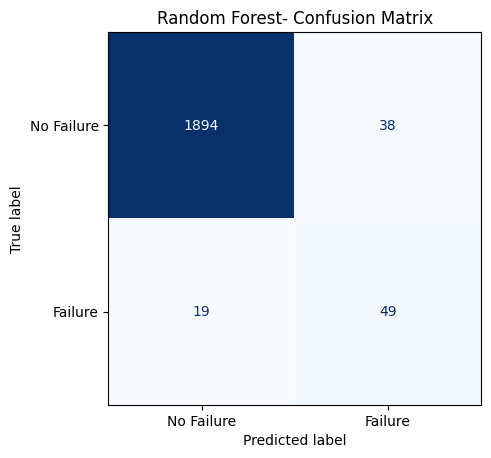

In [17]:
cm = confusion_matrix(y_test,rf_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Failure','Failure'])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Random Forest- Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png',dpi=110)
plt.show()

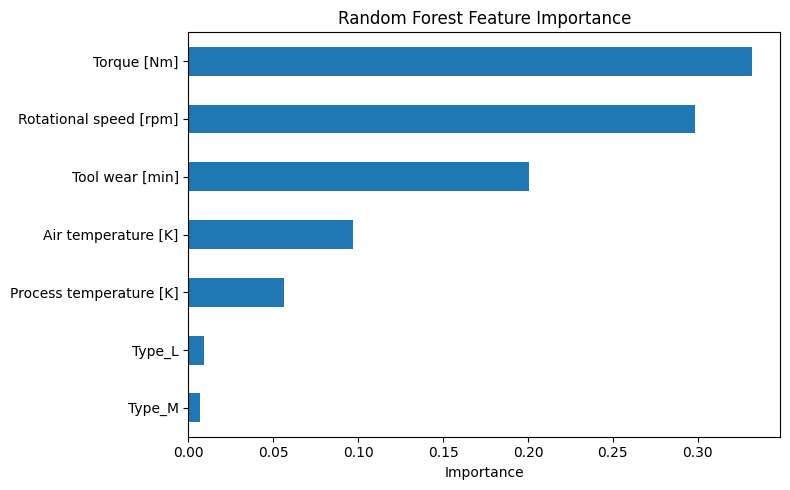

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8,5))
importances.plot(kind='barh')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png',dpi=110)
plt.show()

## 6. Takeaways

Random Forest substantially outperforms Logistic Regression on both precision and F1, it captures non-linear interactions between torque, speed, and tool wear that drive failure.

Logistic Regression catches slightly more failures (higher recall) but at the cost of many false alarms (low precision), a real trade-off maintenance teams face: miss a failure vs. over-trigger inspections.

Torque, rotational speed, and tool wear dominate feature importance - physically sensible, since overstrain and tool-wear failure modes are driven by exactly these variables.

